# HGLM Mandrill Example

This jupyter notebook runs through a simple toy example of a Monkey's face.  Its a great place to get started for technical and non-technical readers alike.  By the end of this notebook you'll have a sense of what problem we're solving and how we approach it.  The included code is helpful if you want to repeat or tweak the experiment, but its not at all necessary to get started.  

# Generating a toy set of images

We begin by loading a single image and coping it `num_img` times to simulate an image population.  We add a bit of noise to each image to simulate having images of different monkey faces.  Notice that the images here are in a registered space, each pixel corresponds to the same anatomical location.  In other words, if we were to imagine stackign the images on top of each other the eye of the monkey, and every other part, would align across images.

In [1]:
import hglm
import pathlib
import numpy as np
from hglm_image_demo import imshow_rgb
import matplotlib.pyplot as plt

seed = 0
num_img = 5
noise_scale = .2

folder = pathlib.Path(hglm.__file__).parents[1] / 'test' / 'data'

# simple explanatory feature, easier graphing
x = np.arange(num_img).reshape((1, num_img))
contrast = np.array([True])

exp = hglm.Experiment.from_search(folder=folder, 
                                  sbj_regex='mandrill_small', 
                                  img_glob_dict={'rgb': 'mandrill_small.png'},
                                  x=x, contrast=contrast, add_bias=True)
exp.bootstrap_img(n=num_img, seed=seed, noise_scale=noise_scale)

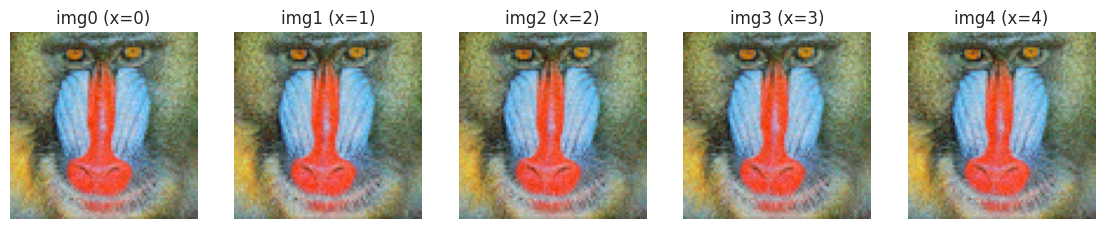

In [2]:
fig, ax = plt.subplots(1, num_img)
fig.set_size_inches(14, 5)
for idx in range(num_img):
    plt.sca(ax[idx])
    imshow_rgb(exp.y[:, idx, :], exp.mask_idx, label=f'img{idx} (x={idx})')

# Problem Statement (What is an "effect"?)

Suppose you hopped into an MRI each day to record an image of your brain.  You might want to see how your brain is changing as you age.  Maybe its the case that there is some region within the images which grow "lighter" or "darker" with age.  Or, more realistically, you might want to compare images of people with and without an illness.  Maybe its the case that the illness impacts some region of the image consistently across individuals.  

In both cases, we are given a population of images (our $y$ feature, image intensity) as well as some explanatory feature(s) ($x$ feature).   Our goal is to identify some set of contiguous pixels in the image whose $y$ is not-just-coincidnetally-correlated with $x$.  Some effects which might be discovered, per our examples above:
- every year older I get, 100 voxels towards the top of my brain get "darker"
- there is a small region of 57 voxels which are consistently "lighter" in people with a given illness

Notice that the effect is encapsulated with two properties:
1. the spatial extent of the effect, where in the image does the effect occur?
1. the mapping from explanatory features $x$ to $y$, how does the effect change the images?

To ask this question properly, one needs a population of images $y$ as well as explanatory features $x$.  In our monkey toy example, we choose a convenient, arbitrary explanatory feature: consecutive integers ($x=0, x=1, x=2, ...$).

This is the General Linear Model ([wikipedia](https://en.wikipedia.org/wiki/General_linear_model), [Winkler 2014](https://pubmed.ncbi.nlm.nih.gov/24530839/)) applied to a population of images.

# Imposing an effect

Of course, the arbitrary choice of $x$ in our monkey image set means that there are currently no effects in the data (any correlation between $x$ and $y$ is coincidiental).  In this section we modify the images to impose an effect.

### Sampling a spatial extent

Effects occur in regions with a consistent color.  For example, an illness might target a particular tissue such that its impacted area follows the anatomical contours of the targeted tissue.  To simulate a realistic effect, we choose an extent whose color is as consistent as possible.  This is achieved by sampling an arbitrary pixel in the image and iteratively incorporating the neighboring pixels whoes color is as similar as possible to those already collected.  The chosen extent is shown below in bright green.

In [3]:
# what percentage of voxels are contained in effect
extent_percent = .1

# effect severity (smaller values yield more obvious effects)
p_val = .01

num_vox = np.prod(exp.mask_idx.shape)
num_vox_eff = extent_percent * num_vox
extenter = hglm.ExtenterMinVar(num_vox_eff)
mask_eff = extenter(y=exp.y, mask_idx=exp.mask_idx, seed=seed, verbose=True)

finding min var extent: 100%|███████████████| 639/639 [00:00<00:00, 2611.31it/s]


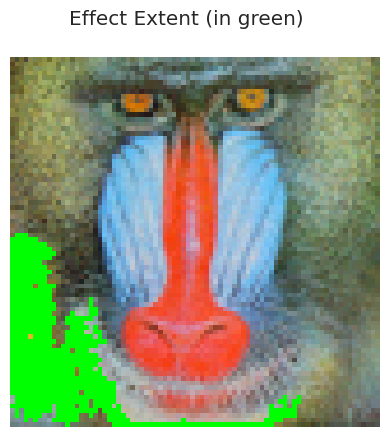

In [4]:
imshow_rgb(exp.y.mean(axis=1), exp.mask_idx, label=None, mask=mask_eff)
plt.suptitle('Effect Extent (in green)');

### Modifying colors to impose correlation between $x$ and $y$

In [5]:
exp_w_effect, effect = exp.impose_effect(seed=seed, mask=mask_eff, p_val=p_val)

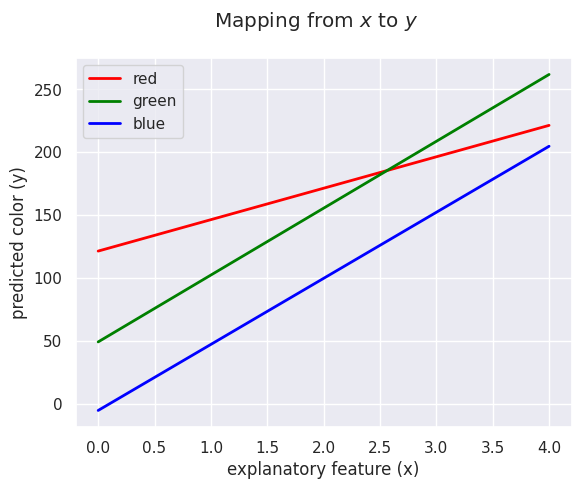

In [6]:
rgb = (effect.beta[1] @ exp.x)
for idx, c in enumerate(['red', 'green', 'blue']):
    plt.plot(exp.x[1, :], rgb[idx, :], c=c, linewidth=2, label=c)
plt.xlabel('explanatory feature (x)')
plt.ylabel('predicted color (y)')
plt.legend()
plt.suptitle('Mapping from $x$ to $y$');

After imposing the effect on the images, the color of the extent is more-than-coincidentally correlated to $x$.  The graph above characterizes the relationship between $x$ and color.  The first monkey image ($x=0$) is expected to have color corresponding to the value of the lines at $x=0$ (i.e. blue=0, green=50, red=125).  It may be more intuitive to see the effect in action on the images themselves.  Observe how color changes as $x$ varies across the population below.

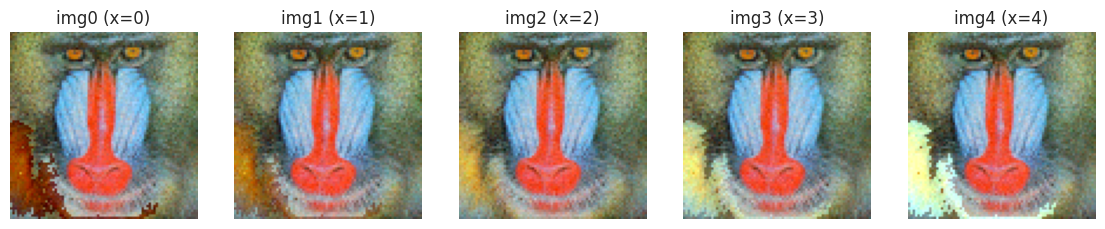

In [7]:
fig, ax = plt.subplots(1, num_img)
fig.set_size_inches(14, 5)
for idx in range(num_img):
    plt.sca(ax[idx])
    imshow_rgb(exp_w_effect.y[:, idx, :], exp_w_effect.mask_idx, label=f'img{idx} (x={idx})')

Note to users who increase the severity of the effect by lowering `p_val`: these rgb values are clipped between 0 and 255 when displayed, you may not be able to see extereme effects for large and small $x$ values.

# Estimating the effect

The challenge of identifying the effect is that, a priori, we know neither the extent nor the mapping (i.e. the red-green-blue line plot above).  

Region Based Analyses split the image into meaningful regions (e.g. via an anatomical atlas) and assess if the effect is contained in any.  The trouble is that these regions may not correspond pixel-to-pixel to our extent.  We'll either split one effect across regions or water down our effect region with other pixels.  In either case, our statistical sensitivity is blunted and the interpretation of results is obfuscated.

Alternatively, one could use a Voxel Based Analysis, building a mapping per individual pixel first and glue-ing voxels together into an extent estimate after the fact (cluster-extent thresholding and TFCE).  The trouble here is that this post-hoc glue-ing together struggles to ensure consistency across the mappings of each pixel.  (This is particularly troubling in a real application, where there may be multiple, adjacent effects!).

In [8]:
n_permute=50
n_permute_z=10
alpha=.05

analysis = hglm.Analysishglm(exp_w_effect, n_permute=n_permute, n_permute_z=n_permute_z, alpha=alpha, verbose=True)

permuting: 100%|████████████████████████████████| 51/51 [00:23<00:00,  2.14it/s]


## HGLM Step 1: Hierarchical Segmentation

HGLM is similar to to the Region Bases Analyses above in that it works from a set of candidate regions in its search for effects.  Unlike these methods, HGLM automatically generates a set of regions from the images themselves.  Ideally, a candidate region's pixel colors are close to the predicted colors via the mapping (i.e. the red-green-blue line plot above).  HGLM constructs regions to minimize this difference, the mean-squared-error of the mapping per region.  Towards this end, HGLM uses Agglomerative Clustering, beginning with a one-pixel-per-region segmentation of the entire image.  The adjacent regions which are most similar are merged into a new region which replaces each of its constituents.  This merging continues until only one region remains (see gif below).  The process is a close cousin of [Ward's Clustering](https://en.wikipedia.org/wiki/Ward%27s_method) (our objective differs slightly, requiring a pre-processing step before we can apply Ward's method).

The fact that the hierarchy's regions intersect each other introduces a challenge to our problem, see "HGLM Step 3" below.

In [10]:
hglm.plot.make_gif(file_out='hglm_image_demo.gif', 
                   children=analysis.child_dict[0], 
                   mask_idx=exp_w_effect.mask_idx,
                   num_vox=num_vox, n_list=50, fps=5)

(In case you have trouble getting the local gif to work, here is a [web link to the same](https://i.ibb.co/6Dbyvjv/hglm-image-demo.gif))

<img src="hglm_image_demo.gif" alt="GIF" loop="3" style="width: 300px; height: auto;">


todo: stopped March 1st, incomplete